In [1]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.neighbors import KNeighborsRegressor
import joblib

# 📌 Kaydedilen Model ve İşlem Adımlarını Yükle
model = joblib.load(r"xgboost_credit_model.pkl")

# 📌 Yeni Veriyi Yükle
new_data = pd.read_csv(r"heloc_dataset_v1.csv")  # Yeni tahmin yapmak istediğiniz veri dosyası

# 📌 Önişleme 
new_data.replace([-9, -8, -7], np.nan, inplace=True)

threshold = 0.15 # Yüzde 10 eşik değeri ile NaN oranı hesaplama
nan_ratio = new_data.isna().mean() # Sütunların NaN oranlarını hesapla
new_data_Clean= new_data.loc[:, nan_ratio <= threshold] # Yüzde 10'tan fazla NaN olan sütunları sil

# 📌 Eksik değerleri doldur
numeric_columns = new_data_Clean.select_dtypes(include=["number"]).columns # Sadece sayısal sütunları seç
imputer = IterativeImputer(estimator=KNeighborsRegressor(),random_state=0)
new_data_Clean[numeric_columns] = imputer.fit_transform(new_data_Clean[numeric_columns]) # interpolate işlemini sayısal sütunlara uygula

new_data_Clean1 = new_data_Clean.drop(columns=["RiskPerformance"]) # Tahmin yapılacak veri setinden hedef sütunu çıkar

# 📌 Modeli Kullanarak Tahmin Yap
predictions = model.predict(new_data_Clean1)

print("📊 Yeni verinin tahminleri:", predictions)


C:\Users\salih\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\core.py:160: UserWarning: [23:31:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  warnings.warn(smsg, UserWarning)


📊 Yeni verinin tahminleri: [0 0 0 ... 0 1 0]


C:\Users\salih\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
C:\Users\salih\AppData\Local\Temp\ipykernel_24844\1295669094.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data_Clean[numeric_columns] = imputer.fit_transform(new_data_Clean[numeric_columns]) # interpolate işlemini sayısal sütunlara uygula


In [2]:
import shap
explainer=shap.TreeExplainer(model)
explaination=explainer(new_data_Clean1)
shap_values = explaination.values
print(np.shape(explaination.values)),
print(shap_values)


(10459, 20)
[[-1.0047108  -0.03017672  0.00848331 ... -0.07159518 -0.11547591
   0.00936913]
 [-0.6133699  -0.4098396  -0.02536958 ... -0.03095206  0.06411321
   0.15866695]
 [-0.24421082 -0.39315248  0.00193293 ...  0.01518285 -0.05713966
  -0.05781964]
 ...
 [ 0.01529836 -0.12385476 -0.01223306 ...  0.01313613  0.11983198
   0.00643235]
 [-0.02107954 -0.02037214 -0.04022195 ... -0.04291658  0.17434803
   0.06805439]
 [-0.2634467  -0.2908182  -0.08354419 ... -0.16604619  0.0813733
  -0.18412898]]


### GLOBAL AÇIKLANABİLİRLİK

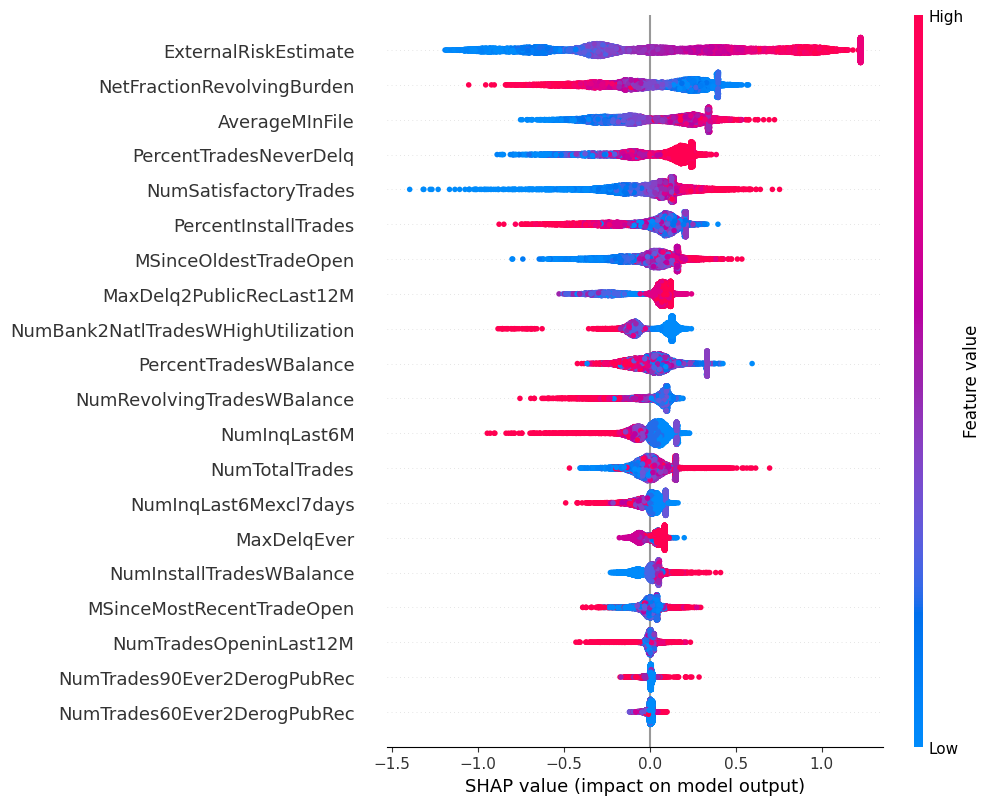

In [3]:
#Model Açıklama Tekniği - beeswarm tekniği
shap.plots.beeswarm(explaination,max_display=len(explaination[0].feature_names))
#global açıklanabilir dosyası

In [4]:
#Model Açıklama tekniği

# SHAP değerlerini DataFrame formatına çevir
shap_values_df = pd.DataFrame(explaination.values, columns=new_data_Clean1.columns)

# Her özelliğin ortalama mutlak SHAP değerini hesapla (önem sırası için)
shap_importance = shap_values_df.abs().mean().sort_values(ascending=False)

# Sonucu göster
shap_importance_df = pd.DataFrame(shap_importance, columns=["Mean |SHAP Value|"])
shap_importance_df.reset_index(inplace=True)
shap_importance_df.rename(columns={"index": "Feature"}, inplace=True)


In [5]:
shap_importance_df
#pd.save_to_excel()
#excele dönüştürüp dosyaya at 
##global açıklanabilir dosyası

,Feature,Mean |SHAP Value|
0,ExternalRiskEstimate,0.544680
1,NetFractionRevolvingBurden,0.241698
2,AverageMInFile,0.227890
3,PercentTradesNeverDelq,0.190675
4,NumSatisfactoryTrades,0.151378
5,PercentInstallTrades,0.148770
6,MSinceOldestTradeOpen,0.119399
7,MaxDelq2PublicRecLast12M,0.118775
8,NumBank2NatlTradesWHighUtilization,0.112538
9,PercentTradesWBalance,0.097878


In [6]:
# Tüm değişkenler için SHAP bağımlılık değerlerini saklamak için bir liste
dependence_data = []

# Her özelliğin bağımlılık değerlerini hesapla
for name in new_data_Clean1.columns:
    shap_values_feature = explaination[:, new_data_Clean1.columns.get_loc(name)].values
    feature_values = new_data_Clean1[name].values
    
    # SHAP değerlerinin ortalamasını ve dağılımını hesapla
    mean_shap = shap_values_feature.mean()
    min_shap = shap_values_feature.min()
    max_shap = shap_values_feature.max()
    
    mean_feature = feature_values.mean()
    min_feature = feature_values.min()
    max_feature = feature_values.max()
    
    # Listeye ekle
    dependence_data.append({
        "Feature": name,
        "Mean SHAP Value": mean_shap,
        "Min SHAP Value": min_shap,
        "Max SHAP Value": max_shap,
        "Mean Feature Value": mean_feature,
        "Min Feature Value": min_feature,
        "Max Feature Value": max_feature
    })

# Sonuçları DataFrame olarak oluştur
shap_dependence_df = pd.DataFrame(dependence_data)


In [7]:
shap_dependence_df
#pd.save_to_excel()
#excele dönüştürüp dosyaya at 
##global açıklanabilir dosyası

,Feature,Mean SHAP Value,Min SHAP Value,Max SHAP Value,Mean Feature Value,Min Feature Value,Max Feature Value
0,ExternalRiskEstimate,0.085218,-1.191058,1.226401,72.632814,33.0,94.0
1,MSinceOldestTradeOpen,0.004757,-0.801380,0.535685,203.359021,2.0,803.0
2,MSinceMostRecentTradeOpen,-0.000165,-0.390101,0.296688,9.409236,0.0,383.0
3,AverageMInFile,0.016902,-0.751742,0.725722,78.903050,4.0,383.0
4,NumSatisfactoryTrades,0.004958,-1.396779,0.755007,21.047175,0.0,79.0
5,NumTrades60Ever2DerogPubRec,-0.001428,-0.118639,0.100600,0.548714,0.0,19.0
6,NumTrades90Ever2DerogPubRec,-0.000886,-0.172909,0.286816,0.363132,0.0,19.0
7,PercentTradesNeverDelq,0.018053,-0.888160,0.386749,92.789464,0.0,100.0
8,MaxDelq2PublicRecLast12M,-0.001082,-0.527814,0.242755,5.827804,0.0,9.0
9,MaxDelqEver,0.003900,-0.177337,0.200438,6.465915,2.0,8.0


### LOCAL AÇIKLANABİLİRLİK

##### 1.satır için 

In [8]:
#Burada 10.index'de bulunan local açıklanabilirlik adımını uyguladık. Sonuç 0'dan büyük olunca "Kredi Kullanılabilir", 0'dan küçük olunca "Kredi Kullanılamaz" Sonucu veriliyor.
#Dolayısıyla 0.71 değerini elde ettiğimiz için kredi kullanılabilir.


# Visualize SHAP values for a single prediction (e.g., the first prediction)
shap.initjs()  # Initialize JavaScript visualization (for Jupyter notebooks)
print("Model tahmini:", "Kredi Kullanılamaz" if predictions[1] == 0 else "Kredi Kullanılabilir") # 0 kötü 1 iyi
shap.force_plot(explainer.expected_value, shap_values[1, :], new_data_Clean1.iloc[11, :])

#matplotlib şekline çevirmeye, png dosyası getirmen lazım

##local açıklanabilir dosyası
#10.satır için
#force_plot-10.satır


Model tahmini: Kredi Kullanılamaz


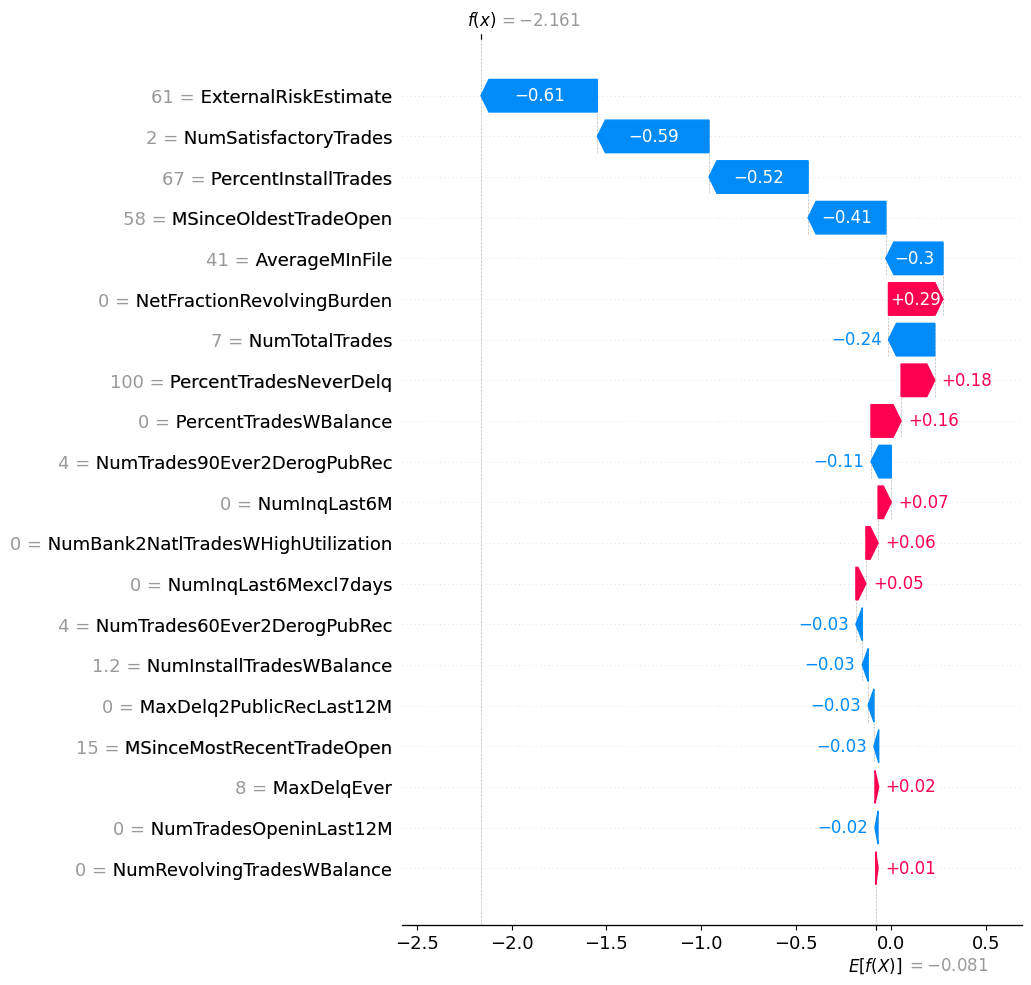

Model tahmini: Kredi Kullanılamaz


In [9]:

#1.veriye ait local açıklanabilirlik tekniği
#hangi sütunlar kredi kullanması için olanak tanımış (kırmızı + olanlar), hangi sütunlar kredi kullanamaması için değerler verilmiş (mavi olanlar) görülüyor.


shap.plots.waterfall(explaination[1], max_display=len(explaination[1].feature_names))

# Ardından tahmin sonucunu yazdırın
print("Model tahmini:", 
      "Kredi Kullanılamaz" if predictions[1] == 0 else "Kredi Kullanılabilir")



##local açıklanabilir dosyası
#1.satır için
#waterfall 1.satır

In [21]:
#1.satır için
shap_values_instance = shap_values[1, :]
feature_values = new_data_Clean1.iloc[1, :]  # Original feature values

# Determine the model prediction (0 = Kredi Kullanılamaz, 1 = Kredi Kullanılabilir)
prediction_label = "Credit Not Available" if predictions[1] == 0 else "Credit Avaible"
proba_predictions = model.predict_proba(new_data_Clean1.iloc[1, :].values.reshape(1, -1))  # Ensure input shape
proba_predictions = proba_predictions[0][1] 

# Create a DataFrame with feature names, values, and SHAP values
shap_df = pd.DataFrame({
    "Feature": feature_values.index,
    "Feature Value": feature_values.values,
    "SHAP Value": shap_values_instance
})

# Create a new row for the model prediction
prediction_row = pd.DataFrame({
    "Feature": ["Model Prediction"],
    "Feature Value": [prediction_label],
    "SHAP Value": [None]  # No SHAP value for this row
})

# Append the prediction probability row to the SHAP DataFrame  
prediction_proba_row = pd.DataFrame({
    "Feature": ["Model Prediction Probability"],
    "Feature Value": [proba_predictions],
    "SHAP Value": [None]  # No SHAP value for this row
})

# Append the prediction row to the SHAP DataFrame
shap_df = pd.concat([shap_df, prediction_row, prediction_proba_row], ignore_index=True)

# Save as CSV (optional)
#shap_df.to_csv("shap_values_with_prediction_row.csv", index=False)

# Display the DataFrame
print(shap_df)

                               Feature         Feature Value SHAP Value
0                 ExternalRiskEstimate                  61.0   -0.61337
1                MSinceOldestTradeOpen                  58.0   -0.40984
2            MSinceMostRecentTradeOpen                  15.0   -0.02537
3                       AverageMInFile                  41.0  -0.300917
4                NumSatisfactoryTrades                   2.0  -0.588019
5          NumTrades60Ever2DerogPubRec                   4.0  -0.033628
6          NumTrades90Ever2DerogPubRec                   4.0  -0.106922
7               PercentTradesNeverDelq                 100.0   0.177556
8             MaxDelq2PublicRecLast12M                   0.0  -0.030233
9                          MaxDelqEver                   8.0   0.019605
10                      NumTotalTrades                   7.0   -0.24416
11              NumTradesOpeninLast12M                   0.0  -0.015986
12                PercentInstallTrades                  67.0  -0

##### 10.satır için

In [11]:
#Burada 10.index'de bulunan local açıklanabilirlik adımını uyguladık. Sonuç 0'dan büyük olunca "Kredi Kullanılabilir", 0'dan küçük olunca "Kredi Kullanılamaz" Sonucu veriliyor.
#Dolayısıyla 0.71 değerini elde ettiğimiz için kredi kullanılabilir.


# Visualize SHAP values for a single prediction (e.g., the first prediction)
shap.initjs()  # Initialize JavaScript visualization (for Jupyter notebooks)
print("Model tahmini:", "Kredi Kullanılamaz" if predictions[10] == 0 else "Kredi Kullanılabilir") # 0 kötü 1 iyi
shap.force_plot(explainer.expected_value, shap_values[10, :], new_data_Clean1.iloc[11, :])

##local açıklanabilir dosyası
#1.satır için


Model tahmini: Kredi Kullanılabilir


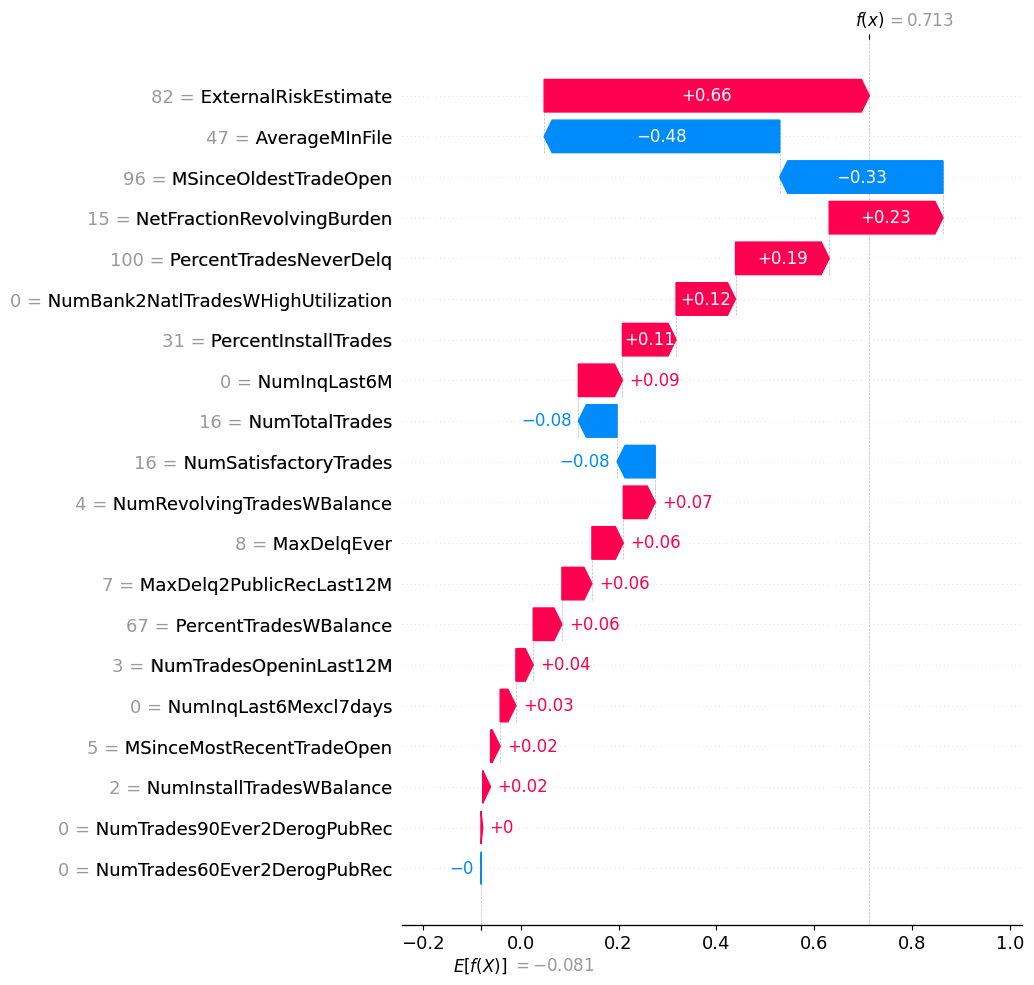

Model tahmini: Kredi Kullanılabilir


In [12]:

#10.veriye ait local açıklanabilirlik tekniği
#hangi sütunlar kredi kullanması için olanak tanımış (kırmızı + olanlar), hangi sütunlar kredi kullanamaması için değerler verilmiş (mavi olanlar) görülüyor.


shap.plots.waterfall(explaination[10], max_display=len(explaination[1].feature_names))

# Ardından tahmin sonucunu yazdırın
print("Model tahmini:", 
      "Kredi Kullanılamaz" if predictions[10] == 0 else "Kredi Kullanılabilir")



##local açıklanabilir dosyası
#1.satır için

In [13]:
#10.satır lokal açıklanabilir


shap_values_instance = shap_values[10, :]
feature_values = new_data_Clean1.iloc[10, :]  # Original feature values

# Determine the model prediction (0 = Kredi Kullanılamaz, 1 = Kredi Kullanılabilir)
prediction_label = "Kredi Kullanılamaz" if predictions[10] == 0 else "Kredi Kullanılabilir"
proba_predictions = model.predict_proba(new_data_Clean1.iloc[-2, :].values.reshape(1, -1))  # Ensure input shape
proba_predictions = proba_predictions[0][1] 

# Create a DataFrame with feature names, values, and SHAP values
shap_df = pd.DataFrame({
    "Feature": feature_values.index,
    "Feature Value": feature_values.values,
    "SHAP Value": shap_values_instance
})

# Create a new row for the model prediction
prediction_row = pd.DataFrame({
    "Feature": ["Model Prediction"],
    "Feature Value": [prediction_label],
    "SHAP Value": [None]  # No SHAP value for this row
})

# Append the prediction probability row to the SHAP DataFrame  
prediction_proba_row = pd.DataFrame({
    "Feature": ["Model Prediction Probability"],
    "Feature Value": [proba_predictions],
    "SHAP Value": [None]  # No SHAP value for this row
})

# Append the prediction row to the SHAP DataFrame
shap_df = pd.concat([shap_df, prediction_row, prediction_proba_row], ignore_index=True)

# Save as CSV (optional)
#shap_df.to_csv("shap_values_with_prediction_row.csv", index=False)

# Display the DataFrame
print(shap_df)

                               Feature         Feature Value SHAP Value
0                 ExternalRiskEstimate                  82.0    0.66477
1                MSinceOldestTradeOpen                  96.0  -0.333625
2            MSinceMostRecentTradeOpen                   5.0   0.019587
3                       AverageMInFile                  47.0  -0.481564
4                NumSatisfactoryTrades                  16.0  -0.077996
5          NumTrades60Ever2DerogPubRec                   0.0  -0.000525
6          NumTrades90Ever2DerogPubRec                   0.0   0.003586
7               PercentTradesNeverDelq                 100.0   0.191463
8             MaxDelq2PublicRecLast12M                   7.0   0.061324
9                          MaxDelqEver                   8.0   0.064193
10                      NumTotalTrades                  16.0  -0.079177
11              NumTradesOpeninLast12M                   3.0   0.035445
12                PercentInstallTrades                  31.0   0